<a href="https://colab.research.google.com/github/Sibitenda/PhDumu/blob/main/big_data/week7_full_pipeline_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Week 7: Real-Time Big Data ML Pipeline (Complete)

This notebook demonstrates a **full big data ML pipeline**:

## Pipeline Overview
1. Data Access (BigQuery)
2. Data Cleaning & EDA
3. Feature Engineering
4. Batch ML (sklearn)
5. Distributed ML (Spark MLlib)
6. Streaming Inference (Spark Structured Streaming)
7. Event-Driven Actions

---

## Key Learning Objective
Understand the difference between:
- Batch ML (correctness)
- Distributed ML (scalability)
- Streaming ML (real-time inference)
- Event-driven systems (actions)


## 1. Setup and BigQuery Access

In [1]:

!pip install -q google-cloud-bigquery pandas matplotlib scikit-learn

from google.colab import auth
auth.authenticate_user()

PROJECT_ID = "bigdata1-491608"

from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Data Access (BigQuery)

In [2]:

query = '''
SELECT country_region, date, confirmed
FROM `bigquery-public-data.covid19_jhu_csse.summary`
WHERE date >= '2021-01-01'
LIMIT 2000
'''

df = client.query(query).to_dataframe()
df.head()


,country_region,date,confirmed
0,Italy,2021-08-02,76292
1,Italy,2021-05-14,73030
2,Italy,2021-06-20,74628
3,Italy,2021-05-12,72799
4,Italy,2021-06-09,74362


## 3. Data Cleaning

In [3]:

df = df.dropna()
df = df[df['confirmed'] > 0]
print("Cleaned shape:", df.shape)


Cleaned shape: (2000, 3)


## 4. Exploratory Data Analysis

In [4]:

df.describe()


,confirmed
count,2000.0
mean,159119.5275
std,370111.997492
min,17.0
25%,7995.0
50%,36970.0
75%,146949.5
max,4891810.0


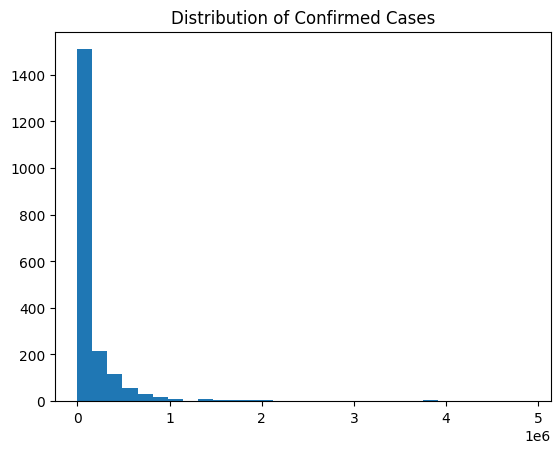

In [5]:

plt.hist(df['confirmed'], bins=30)
plt.title("Distribution of Confirmed Cases")
plt.show()


## 5. Feature Engineering

In [6]:

df['log_confirmed'] = np.log(df['confirmed'])

df['date'] = pd.to_datetime(df['date'])
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month

df['severity'] = pd.qcut(df['confirmed'], 3, labels=["Low","Medium","High"])
df.head()


,country_region,date,confirmed,log_confirmed,day,month,severity
0,Italy,2021-08-02,76292,11.242323,2,8,Medium
1,Italy,2021-05-14,73030,11.198626,14,5,Medium
2,Italy,2021-06-20,74628,11.220271,20,6,Medium
3,Italy,2021-05-12,72799,11.195457,12,5,Medium
4,Italy,2021-06-09,74362,11.2167,9,6,Medium


## 6. Batch ML (sklearn)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Features and target
X = df[['confirmed','log_confirmed','day','month']]
y = df['severity']

# Train/Test split (IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n= {name} ")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))

# Summary comparison
print("\n MODEL COMPARISON ")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")


= Random Forest 
Accuracy: 1.0000
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       134
         Low       1.00      1.00      1.00       133
      Medium       1.00      1.00      1.00       133

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


= Logistic Regression 
Accuracy: 0.9850
              precision    recall  f1-score   support

        High       1.00      0.96      0.98       134
         Low       0.99      1.00      1.00       133
      Medium       0.96      0.99      0.98       133

    accuracy                           0.98       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.98      0.98       400


= Decision Tree 
Accuracy: 1.0000
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       134
         Low      

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 BATCH 1 
RF Accuracy: 1.0000
ALERT: 27 high severity cases detected!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR Accuracy: 1.0000
ALERT: 27 high severity cases detected!
DT Accuracy: 1.0000
ALERT: 27 high severity cases detected!


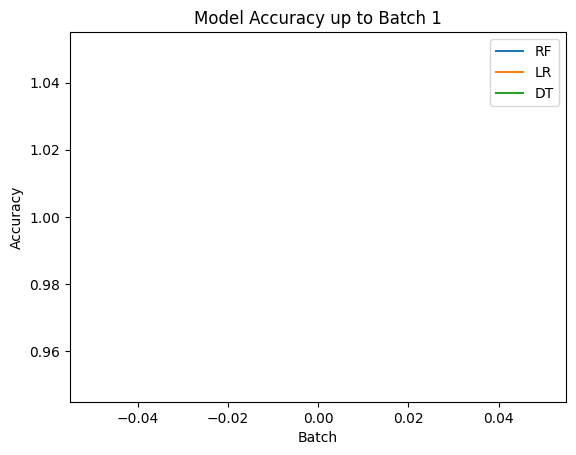


 BATCH 2 
RF Accuracy: 1.0000
ALERT: 44 high severity cases detected!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR Accuracy: 1.0000
ALERT: 44 high severity cases detected!
DT Accuracy: 1.0000
ALERT: 44 high severity cases detected!


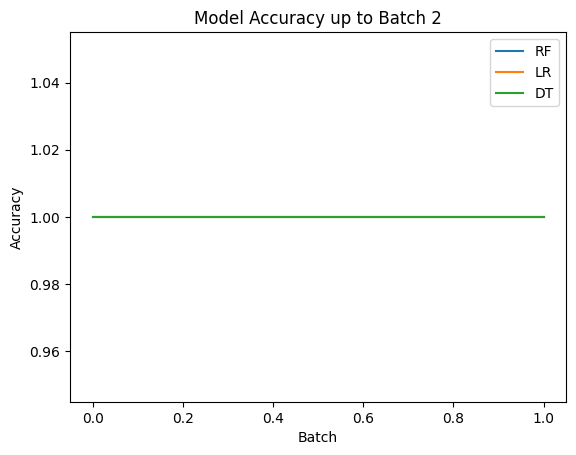


 BATCH 3 
RF Accuracy: 0.9900
ALERT: 41 high severity cases detected!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR Accuracy: 0.9800
ALERT: 40 high severity cases detected!
DT Accuracy: 0.9900
ALERT: 41 high severity cases detected!


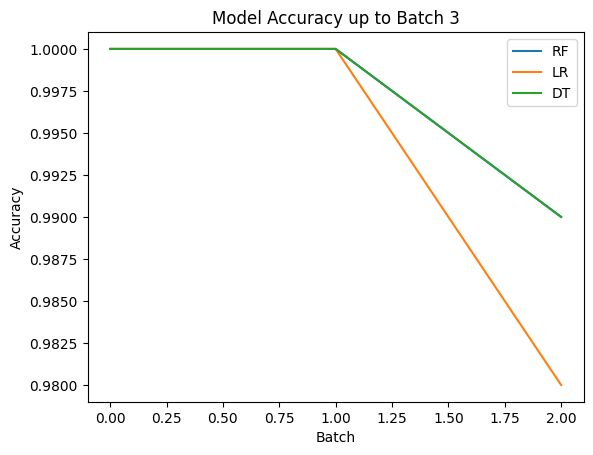


 BATCH 4 
RF Accuracy: 1.0000
ALERT: 33 high severity cases detected!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR Accuracy: 1.0000
ALERT: 33 high severity cases detected!
DT Accuracy: 1.0000
ALERT: 33 high severity cases detected!


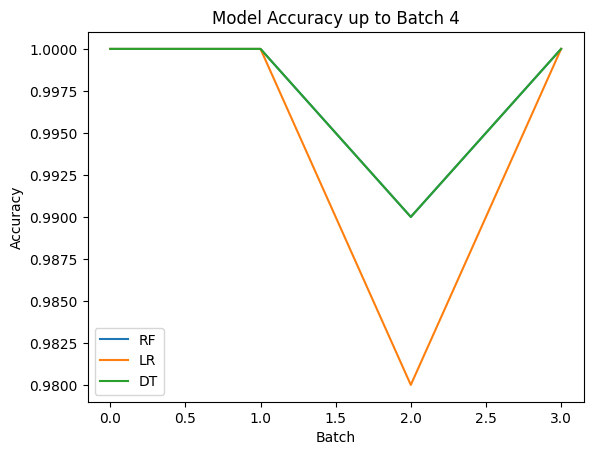


 BATCH 5 
RF Accuracy: 1.0000
ALERT: 32 high severity cases detected!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR Accuracy: 0.9900
ALERT: 32 high severity cases detected!
DT Accuracy: 1.0000
ALERT: 32 high severity cases detected!


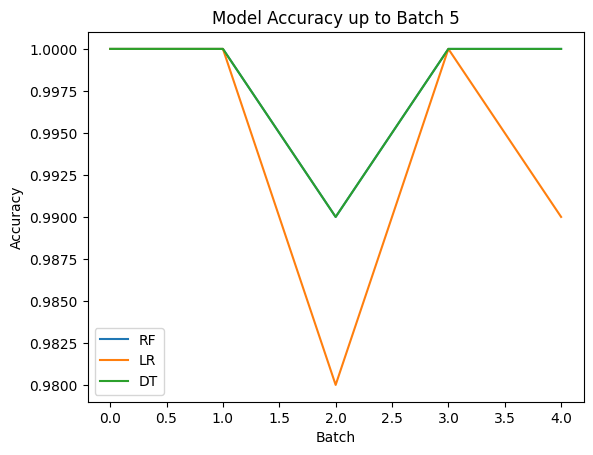

In [31]:
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

batch_size = 500
num_batches = 5

all_results = {name: [] for name in models}

def fetch_batch(offset, limit=500):
    query = f"""
    SELECT country_region, date, confirmed
    FROM `bigquery-public-data.covid19_jhu_csse.summary`
    WHERE date >= '2021-01-01'
    LIMIT {limit} OFFSET {offset}
    """
    df = client.query(query).to_dataframe()
    return df

def preprocess(df):
    df = df.dropna()
    df = df[df['confirmed'] > 0]

    df['log_confirmed'] = np.log(df['confirmed'])

    df['date'] = pd.to_datetime(df['date'])
    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month

    df['severity'] = pd.qcut(df['confirmed'], 3, labels=["Low","Medium","High"])

    return df

models = {
    "RF": RandomForestClassifier(random_state=42),
    "LR": LogisticRegression(max_iter=1000),
    "DT": DecisionTreeClassifier(random_state=42)
}
all_results = {name: [] for name in models}

for i in range(num_batches):
    print(f"\n BATCH {i+1} ")


    # Step 1: Fetch new data
    df_batch = fetch_batch(offset=i*batch_size, limit=batch_size)


    # Step 2: Preprocess
    df_batch = preprocess(df_batch)

    X = df_batch[['confirmed','log_confirmed','day','month']]
    y = df_batch['severity']

    # Step 3: Train/Test split

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Step 4: Train + Evaluate
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        all_results[name].append(acc)

        print(f"{name} Accuracy: {acc:.4f}")


        # Step 5: Event-driven trigger
        high_cases = (preds == "High").sum()
        if high_cases > 10:
            print(f"ALERT: {high_cases} high severity cases detected!")


    # Step 6: Visualization
    plt.figure()
    for name, scores in all_results.items():
        plt.plot(scores, label=name)

    plt.title(f"Model Accuracy up to Batch {i+1}")
    plt.xlabel("Batch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


    # Step 7: Simulate real-time delay
    time.sleep(2)

## 7. Setup Spark

In [16]:

!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz
!pip install -q findspark

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("BigDataML").getOrCreate()


## 8. Convert to Spark DataFrame

In [17]:

spark_df = spark.createDataFrame(df)
spark_df.show(5)


+--------------+-------------------+---------+------------------+---+-----+--------+
|country_region|               date|confirmed|     log_confirmed|day|month|severity|
+--------------+-------------------+---------+------------------+---+-----+--------+
|         Italy|2021-08-02 00:00:00|    76292|11.242323362496316|  2|    8|  Medium|
|         Italy|2021-05-14 00:00:00|    73030|11.198625594614155| 14|    5|  Medium|
|         Italy|2021-06-20 00:00:00|    74628| 11.22027105089189| 20|    6|  Medium|
|         Italy|2021-05-12 00:00:00|    72799|11.195457497826698| 12|    5|  Medium|
|         Italy|2021-06-09 00:00:00|    74362|11.216700337654427|  9|    6|  Medium|
+--------------+-------------------+---------+------------------+---+-----+--------+
only showing top 5 rows



## 9. Distributed ML (Spark MLlib)

In [18]:

from pyspark.ml.feature import StringIndexer, VectorAssembler

# Convert target (severity) → numeric label
indexer = StringIndexer(inputCol="severity", outputCol="label")
spark_df = indexer.fit(spark_df).transform(spark_df)

# Assemble features into vector
assembler = VectorAssembler(
    inputCols=["confirmed", "log_confirmed", "day", "month"],
    outputCol="features"
)

spark_df = assembler.transform(spark_df)


# 2. TRAIN / TEST SPLIT
train_df, test_df = spark_df.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())


# 3. DEFINE MODELS
from pyspark.ml.classification import (
    RandomForestClassifier,
    DecisionTreeClassifier,
    LogisticRegression
)

models = {
    "Random Forest": RandomForestClassifier(
        labelCol="label", featuresCol="features", numTrees=20
    ),
    "Decision Tree": DecisionTreeClassifier(
        labelCol="label", featuresCol="features"
    ),
    "Logistic Regression": LogisticRegression(
        labelCol="label", featuresCol="features", maxIter=100
    )
}


# 4. EVALUATION SETUP
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

results = {}


# 5. TRAIN + EVALUATE MODELS
for name, model in models.items():
    print(f"\n {name} ")

    # Train
    fitted_model = model.fit(train_df)

    # Predict
    preds = fitted_model.transform(test_df)

    # Evaluate
    acc = evaluator_acc.evaluate(preds)
    f1 = evaluator_f1.evaluate(preds)

    results[name] = {"accuracy": acc, "f1": f1}

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")

    preds.select("label", "prediction").show(5)


# 6. MODEL COMPARISON
print("\n FINAL MODEL COMPARISON ")

for name, metrics in results.items():
    print(f"{name}: Accuracy={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}")

Training rows: 1642
Testing rows: 358

 Random Forest 
Accuracy: 0.9777
F1 Score: 0.9775
+-----+----------+
|label|prediction|
+-----+----------+
|  2.0|       2.0|
|  2.0|       2.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 5 rows


 Decision Tree 
Accuracy: 0.9749
F1 Score: 0.9747
+-----+----------+
|label|prediction|
+-----+----------+
|  2.0|       2.0|
|  2.0|       2.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 5 rows


 Logistic Regression 
Accuracy: 1.0000
F1 Score: 1.0000
+-----+----------+
|label|prediction|
+-----+----------+
|  2.0|       2.0|
|  2.0|       2.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 5 rows


 FINAL MODEL COMPARISON 
Random Forest: Accuracy=0.9777, F1=0.9775
Decision Tree: Accuracy=0.9749, F1=0.9747
Logistic Regression: Accuracy=1.0000, F1=1.0000


## 10. Streaming Inference (Spark)


===== SPARK BATCH 1 =====
RF Accuracy: 0.9756
 ALERT (Spark): 32 high severity events detected!
DT Accuracy: 0.9390
 ALERT (Spark): 31 high severity events detected!
LR Accuracy: 1.0000
 ALERT (Spark): 32 high severity events detected!


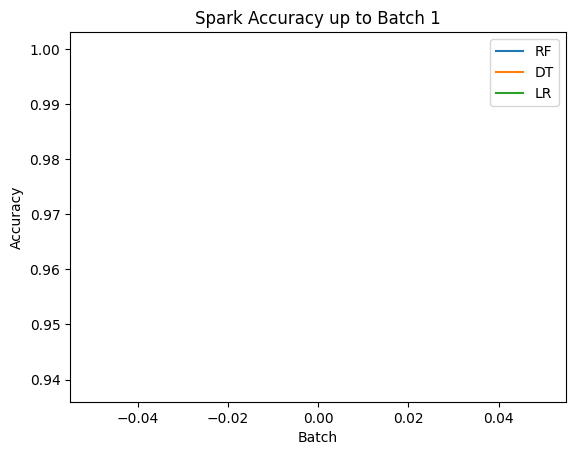


===== SPARK BATCH 2 =====
RF Accuracy: 0.9634
 ALERT (Spark): 25 high severity events detected!
DT Accuracy: 0.9878
 ALERT (Spark): 27 high severity events detected!
LR Accuracy: 1.0000
 ALERT (Spark): 28 high severity events detected!


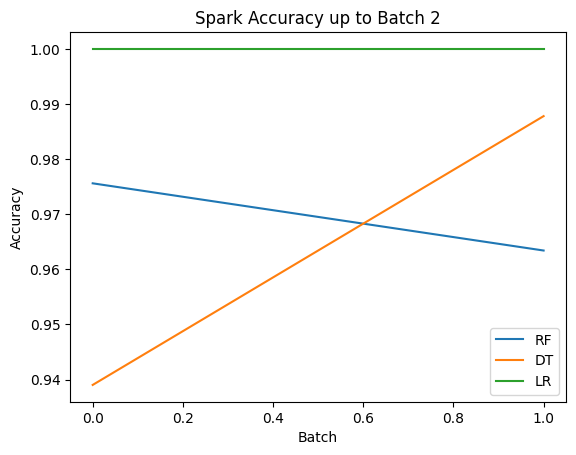


===== SPARK BATCH 3 =====
RF Accuracy: 0.9756
 ALERT (Spark): 22 high severity events detected!
DT Accuracy: 0.9756
 ALERT (Spark): 22 high severity events detected!
LR Accuracy: 0.9878
 ALERT (Spark): 23 high severity events detected!


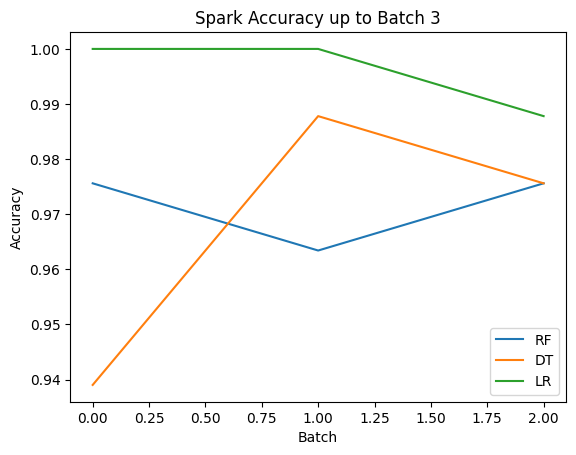


===== SPARK BATCH 4 =====
RF Accuracy: 0.9634
 ALERT (Spark): 23 high severity events detected!
DT Accuracy: 0.9756
 ALERT (Spark): 24 high severity events detected!
LR Accuracy: 0.9878
 ALERT (Spark): 25 high severity events detected!


Exception ignored in: <function JavaWrapper.__del__ at 0x7968db5c0360>
Traceback (most recent call last):
  File "/content/spark-3.5.0-bin-hadoop3/python/pyspark/ml/wrapper.py", line 53, in __del__
    if SparkContext._active_spark_context and self._java_obj is not None:
                                              ^^^^^^^^^^^^^^
AttributeError: 'RandomForestClassifier' object has no attribute '_java_obj'


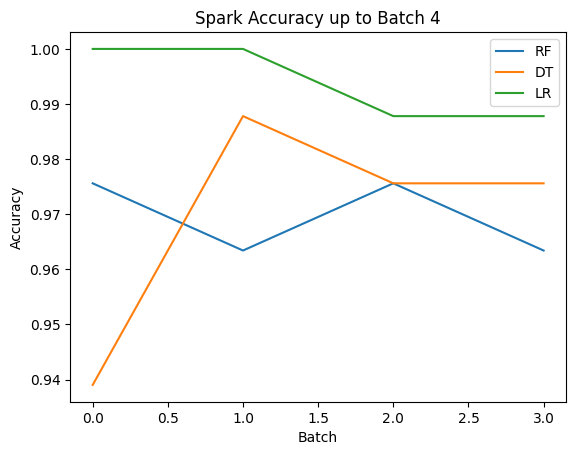


===== SPARK BATCH 5 =====
RF Accuracy: 0.9878
 ALERT (Spark): 29 high severity events detected!
DT Accuracy: 0.9878
 ALERT (Spark): 29 high severity events detected!
LR Accuracy: 1.0000
 ALERT (Spark): 30 high severity events detected!


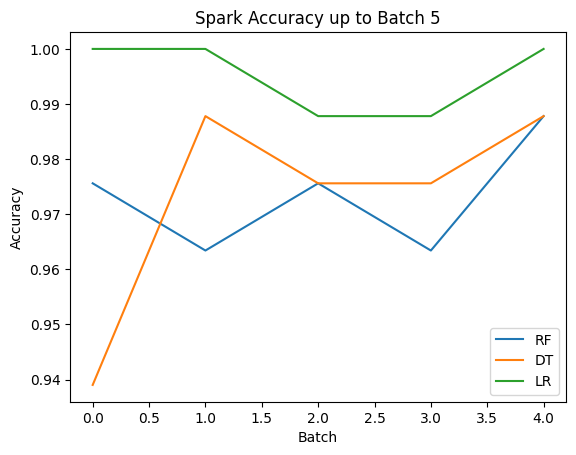

In [32]:

import numpy as np
import matplotlib.pyplot as plt

from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import (
    RandomForestClassifier,
    DecisionTreeClassifier,
    LogisticRegression
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def fetch_batch(offset, limit=500):
    query = f"""
    SELECT country_region, date, confirmed
    FROM `bigquery-public-data.covid19_jhu_csse.summary`
    WHERE date >= '2021-01-01'
    LIMIT {limit} OFFSET {offset}
    """
    return client.query(query).to_dataframe()

def preprocess(df):
    df = df.dropna()
    df = df[df['confirmed'] > 0]

    df['log_confirmed'] = np.log(df['confirmed'])

    df['date'] = pd.to_datetime(df['date'])
    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month

    df['severity'] = pd.qcut(df['confirmed'], 3, labels=["Low","Medium","High"])

    return df

models = {
    "RF": RandomForestClassifier(labelCol="label", featuresCol="features"),
    "DT": DecisionTreeClassifier(labelCol="label", featuresCol="features"),
    "LR": LogisticRegression(labelCol="label", featuresCol="features", maxIter=100)
}

all_results_spark = {name: [] for name in models}

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

batch_size = 500
num_batches = 5

for i in range(num_batches):
    print(f"\n SPARK BATCH {i+1} ")


    # Step 1: Fetch data
    df_batch = fetch_batch(offset=i*batch_size, limit=batch_size)


    # Step 2: Preprocess
    df_batch = preprocess(df_batch)

    # Convert to Spark
    spark_df = spark.createDataFrame(df_batch)


    # Step 3: Feature prep
    indexer = StringIndexer(inputCol="severity", outputCol="label")
    spark_df = indexer.fit(spark_df).transform(spark_df)

    assembler = VectorAssembler(
        inputCols=["confirmed","log_confirmed","day","month"],
        outputCol="features"
    )

    spark_df = assembler.transform(spark_df)


    # Step 4: Train/Test split
    train_df, test_df = spark_df.randomSplit([0.8, 0.2], seed=42)


    # Step 5: Train + Evaluate
    for name, model in models.items():
        fitted = model.fit(train_df)
        preds = fitted.transform(test_df)

        acc = evaluator.evaluate(preds)
        all_results_spark[name].append(acc)

        print(f"{name} Accuracy: {acc:.4f}")


        # Step 6: Event-driven logic
        high_cases = preds.filter(preds["prediction"] == 2).count()

        if high_cases > 10:
            print(f" ALERT (Spark): {high_cases} high severity events detected!")


    # Step 7: Visualization
    plt.figure()
    for name, scores in all_results_spark.items():
        plt.plot(scores, label=name)

    plt.title(f"Spark Accuracy up to Batch {i+1}")
    plt.xlabel("Batch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


    # Step 8: Delay
    time.sleep(2)

In [33]:
# Streaming Source (Kafka-like simulation)
from pyspark.sql.functions import rand, expr, when

stream_df = spark.readStream \
    .format("rate") \
    .option("rowsPerSecond", 5) \
    .load()

In [34]:
# Generate Real-Time Features
stream_df = stream_df \
    .withColumn("confirmed", (rand()*1000).cast("int")) \
    .withColumn("log_confirmed", expr("log(confirmed + 1)")) \
    .withColumn("day", (rand()*30 + 1).cast("int")) \
    .withColumn("month", (rand()*12 + 1).cast("int"))

In [35]:
# Apply Feature Pipeline
stream_features = assembler.transform(stream_df)

In [37]:
# Apply Trained Model (KEY STEP)
stream_preds = model_spark.transform(stream_features)

In [39]:
# Event-Driven Logic
stream_preds = stream_preds.withColumn(
    "alert",
    when(stream_preds["prediction"] == 2, " HIGH ALERT").otherwise("NORMAL")
)


In [49]:
# Output Streaming Results
query = stream_preds.select(
        "timestamp",
        "confirmed",
        "prediction",
        "alert"
    ) \
    .writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", False) \
    .start()

query.awaitTermination(30)
query.stop()

In [51]:
stream_preds

DataFrame[timestamp: timestamp, value: bigint, confirmed: int, log_confirmed: double, day: int, month: int, features: vector, rawPrediction: vector, probability: vector, prediction: double, alert: string]

In [52]:
spark.sql("SELECT * FROM predictions_table LIMIT 10").show()

+--------------------+-----+---------+------------------+---+-----+--------------------+--------------------+--------------------+----------+------+
|           timestamp|value|confirmed|     log_confirmed|day|month|            features|       rawPrediction|         probability|prediction| alert|
+--------------------+-----+---------+------------------+---+-----+--------------------+--------------------+--------------------+----------+------+
|2026-05-02 16:27:...|    0|      726| 6.588926477533519|  6|    7|[726.0,6.58892647...|[0.0,19.886494572...|[0.0,0.9943247286...|       1.0|NORMAL|
|2026-05-02 16:27:...|    2|      113| 4.736198448394496| 16|   12|[113.0,4.73619844...|[0.0,19.902046013...|[0.0,0.9951023006...|       1.0|NORMAL|
|2026-05-02 16:27:...|    4|      673| 6.513230110912307| 29|   12|[673.0,6.51323011...|[0.0,19.902046013...|[0.0,0.9951023006...|       1.0|NORMAL|
|2026-05-02 16:27:...|    1|      173| 5.159055299214529| 28|    9|[173.0,5.15905529...|[0.0,19.902046013.

In [55]:
spark.sql("""
SELECT *
FROM predictions_table
WHERE prediction = 1.0
""").show()

+--------------------+-----+---------+------------------+---+-----+--------------------+--------------------+--------------------+----------+------+
|           timestamp|value|confirmed|     log_confirmed|day|month|            features|       rawPrediction|         probability|prediction| alert|
+--------------------+-----+---------+------------------+---+-----+--------------------+--------------------+--------------------+----------+------+
|2026-05-02 16:27:...|    0|      726| 6.588926477533519|  6|    7|[726.0,6.58892647...|[0.0,19.886494572...|[0.0,0.9943247286...|       1.0|NORMAL|
|2026-05-02 16:27:...|    2|      113| 4.736198448394496| 16|   12|[113.0,4.73619844...|[0.0,19.902046013...|[0.0,0.9951023006...|       1.0|NORMAL|
|2026-05-02 16:27:...|    4|      673| 6.513230110912307| 29|   12|[673.0,6.51323011...|[0.0,19.902046013...|[0.0,0.9951023006...|       1.0|NORMAL|
|2026-05-02 16:27:...|    1|      173| 5.159055299214529| 28|    9|[173.0,5.15905529...|[0.0,19.902046013.


## 13. Summary

This notebook demonstrated:

✔ Batch ML (sklearn)  
✔ Distributed ML (Spark)  
✔ Streaming inference  
✔ Event-driven ML systems  

---

### Final Architecture

BigQuery → Batch ML → Spark ML → Streaming → Event-driven Actions
